In [1]:
import numpy as np
import pandas as pd

In [2]:
train_df= pd.read_csv('PubMed_20k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_20k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_20k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24293578,24293578_0_12,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,24293578,24293578_1_12,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,24293578,24293578_2_12,Outcome measures included pain reduction and i...,2,12,METHODS
3,24293578,24293578_3_12,Pain was assessed using the visual analog pain...,3,12,METHODS
4,24293578,24293578_4_12,Secondary outcome measures included the Wester...,4,12,METHODS


In [3]:
print(train_df.describe())
print(train_df.info())

        abstract_id    line_number    total_lines
count  1.800400e+05  180040.000000  180040.000000
mean   2.501496e+07       5.894568      12.789136
std    5.153296e+05       4.127672       3.236095
min    2.421977e+07       0.000000       4.000000
25%    2.458516e+07       3.000000      11.000000
50%    2.495697e+07       6.000000      12.000000
75%    2.539212e+07       9.000000      15.000000
max    2.652916e+07      30.000000      31.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180040 entries, 0 to 180039
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   abstract_id    180040 non-null  int64 
 1   line_id        180040 non-null  object
 2   abstract_text  180040 non-null  object
 3   line_number    180040 non-null  int64 
 4   total_lines    180040 non-null  int64 
 5   target         180040 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.2+ MB
None


In [4]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  3.021200e+04  30212.000000  30212.000000
mean   2.502800e+07      5.930988     12.861975
std    5.098474e+05      4.142448      3.220353
min    2.421989e+07      0.000000      4.000000
25%    2.460663e+07      3.000000     11.000000
50%    2.498672e+07      6.000000     12.000000
75%    2.540678e+07      9.000000     15.000000
max    2.652158e+07     26.000000     27.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30212 entries, 0 to 30211
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30212 non-null  int64 
 1   line_id        30212 non-null  object
 2   abstract_text  30212 non-null  object
 3   line_number    30212 non-null  int64 
 4   total_lines    30212 non-null  int64 
 5   target         30212 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [5]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  3.013500e+04  30135.000000  30135.000000
mean   2.504292e+07      5.922980     12.845960
std    5.209988e+05      4.141561      3.232885
min    2.422001e+07      0.000000      4.000000
25%    2.461834e+07      3.000000     11.000000
50%    2.500021e+07      6.000000     12.000000
75%    2.542062e+07      9.000000     15.000000
max    2.652158e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30135 entries, 0 to 30134
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    30135 non-null  int64 
 1   line_id        30135 non-null  object
 2   abstract_text  30135 non-null  object
 3   line_number    30135 non-null  int64 
 4   total_lines    30135 non-null  int64 
 5   target         30135 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [6]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
train_df.head()

,abstract_text,line_number,total_lines,target
0,To investigate the efficacy of 6 weeks of dail...,0,12,OBJECTIVE
1,A total of 125 patients with primary knee OA w...,1,12,METHODS
2,Outcome measures included pain reduction and i...,2,12,METHODS
3,Pain was assessed using the visual analog pain...,3,12,METHODS
4,Secondary outcome measures included the Wester...,4,12,METHODS


In [7]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

2026-02-26 10:30:02.011119: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 10:30:02.033485: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 10:30:02.411766: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [8]:
train_sentences = train_df["abstract_text"].tolist()
train_labels = train_df["target"].tolist()

val_sentences = dev_df["abstract_text"].tolist()
val_labels = dev_df["target"].tolist()

In [9]:
print(len(train_sentences))
print(len(train_labels))
print(len(val_sentences))
print(len(val_labels))

180040
180040
30212
30212


## Step 3: Encode Labels

In [10]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)

train_labels_onehot = to_categorical(train_labels_encoded)
val_labels_onehot = to_categorical(val_labels_encoded)

## Step 4: Tokenization

In [11]:
max_vocab = 20000
tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences = tokenizer.texts_to_sequences(val_sentences)

## Step 5: Padding


In [12]:
max_length = 100
train_padded = pad_sequences(train_sequences, maxlen= max_length, padding= "post")
val_padded = pad_sequences(val_sequences, maxlen= max_length, padding = "post")

## Build The LSTM Model
### Simple LSTM Architecture

In [13]:
model = tf.keras.Sequential([layers.Embedding(input_dim = max_vocab, output_dim = 128, input_length = max_length),
                             layers.LSTM(128),
                             layers.Dense(64, activation = "relu"),
                             layers.Dense(5, activation = "softmax")])

2026-02-26 10:30:08.113017: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-26 10:30:08.134829: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-02-26 10:30:08.271725: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gra

In [14]:
## Comile Model
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics = ["accuracy"])

In [15]:
# Training
history = model.fit(train_padded, train_labels_onehot,
                    validation_data=(val_padded, val_labels_onehot),
                    epochs = 5,
                    batch_size = 256)

Epoch 1/5


2026-02-26 10:30:08.834627: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:30:08.835604: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:30:08.836220: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

703/704 [============================>.] - ETA: 0s - loss: 1.4708 - accuracy: 0.3275

2026-02-26 10:31:45.094067: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:31:45.095019: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:31:45.095626: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

704/704 [==============================] - 102s 144ms/step - loss: 1.4708 - accuracy: 0.3275 - val_loss: 1.4634 - val_accuracy: 0.3338
Epoch 2/5
704/704 [==============================] - 83s 118ms/step - loss: 1.3636 - accuracy: 0.3867 - val_loss: 0.7561 - val_accuracy: 0.6763
Epoch 3/5
704/704 [==============================] - 85s 121ms/step - loss: 0.5782 - accuracy: 0.7789 - val_loss: 0.5167 - val_accuracy: 0.8040
Epoch 4/5
704/704 [==============================] - 84s 120ms/step - loss: 0.4410 - accuracy: 0.8412 - val_loss: 0.4813 - val_accuracy: 0.8262
Epoch 5/5
704/704 [==============================] - 85s 121ms/step - loss: 0.3784 - accuracy: 0.8665 - val_loss: 0.4982 - val_accuracy: 0.8260


In [16]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

 13/945 [..............................] - ETA: 8s

2026-02-26 10:37:28.374462: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:37:28.375057: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:37:28.375603: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

945/945 [==============================] - 8s 9ms/step


In [17]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [18]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.64      0.67      0.65      3449
 CONCLUSIONS       0.73      0.77      0.75      4582
     METHODS       0.91      0.90      0.90      9964
   OBJECTIVE       0.74      0.56      0.63      2376
     RESULTS       0.88      0.90      0.89      9841

    accuracy                           0.83     30212
   macro avg       0.78      0.76      0.76     30212
weighted avg       0.83      0.83      0.82     30212



In [19]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[2294  577  163  390   25]
 [ 388 3538   78   12  566]
 [ 167  135 8960   68  634]
 [ 727  200  110 1320   19]
 [  36  417  542    2 8844]]


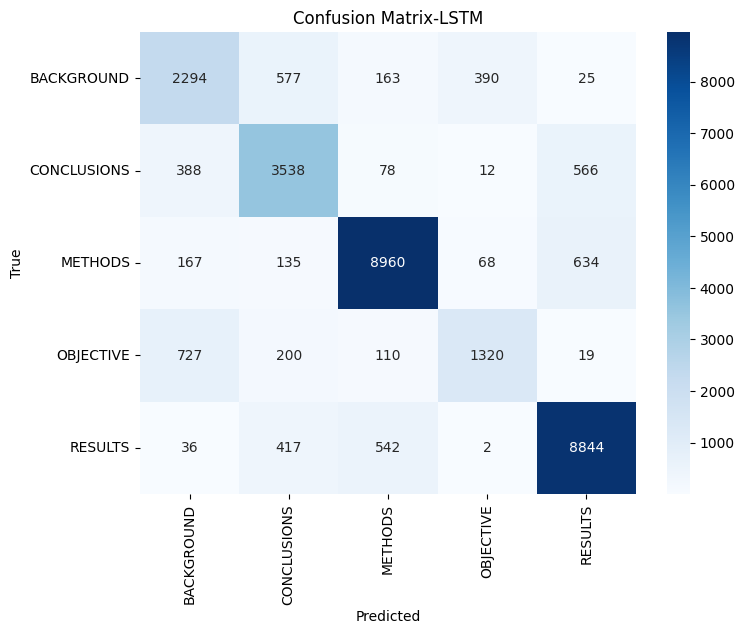

In [20]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [21]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.665120
CONCLUSIONS: 0.772152
METHODS: 0.899237
OBJECTIVE: 0.555556
RESULTS: 0.898689


In [22]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.8260293922944525


In [23]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.76477017236619
Weighted F1: 0.8248993071949969


## Using Bidirectional Model

In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers

In [25]:
train_sentences = train_df["abstract_text"].astype(str).values
val_sentences   = dev_df["abstract_text"].astype(str).values
test_sentences  = test_df["abstract_text"].astype(str).values

train_labels = train_df["target"].values
val_labels   = dev_df["target"].values
test_labels  = test_df["target"].values

In [26]:
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_labels)
val_labels_encoded   = label_encoder.transform(val_labels)
test_labels_encoded  = label_encoder.transform(test_labels)

print(label_encoder.classes_)

['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']


In [27]:
max_vocab = 20000

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(train_sentences)

train_sequences = tokenizer.texts_to_sequences(train_sentences)
val_sequences   = tokenizer.texts_to_sequences(val_sentences)
test_sequences  = tokenizer.texts_to_sequences(test_sentences)

In [28]:
max_length = 100

train_padded = pad_sequences(train_sequences, maxlen=max_length, padding="post")
val_padded   = pad_sequences(val_sequences, maxlen=max_length, padding="post")
test_padded  = pad_sequences(test_sequences, maxlen=max_length, padding="post")

In [29]:
train_padded = np.array(train_padded, dtype=np.int32)
val_padded   = np.array(val_padded, dtype=np.int32)
test_padded  = np.array(test_padded, dtype=np.int32)

train_labels_encoded = np.array(train_labels_encoded, dtype=np.int32)
val_labels_encoded   = np.array(val_labels_encoded, dtype=np.int32)
test_labels_encoded  = np.array(test_labels_encoded, dtype=np.int32)

In [30]:
model = tf.keras.Sequential([
    
    layers.Embedding(
        input_dim=max_vocab,
        output_dim=128,
        input_length=max_length
    ),
    
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    
    layers.Dropout(0.5),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dense(5, activation="softmax")
])


2026-02-26 10:37:45.750639: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:37:45.751466: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:37:45.752035: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [31]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [32]:
history = model.fit(
    train_padded,
    train_labels_encoded,
    validation_data=(val_padded, val_labels_encoded),
    epochs=5,
    batch_size=256
)

Epoch 1/5


2026-02-26 10:37:46.746186: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:37:46.747025: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:37:46.747693: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

704/704 [==============================] - ETA: 0s - loss: 0.6289 - accuracy: 0.7644

2026-02-26 10:40:26.437365: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:40:26.438212: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:40:26.438776: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

704/704 [==============================] - 172s 241ms/step - loss: 0.6289 - accuracy: 0.7644 - val_loss: 0.4792 - val_accuracy: 0.8254
Epoch 2/5
704/704 [==============================] - 171s 243ms/step - loss: 0.4454 - accuracy: 0.8416 - val_loss: 0.4687 - val_accuracy: 0.8273
Epoch 3/5
704/704 [==============================] - 206s 293ms/step - loss: 0.3822 - accuracy: 0.8662 - val_loss: 0.4743 - val_accuracy: 0.8287
Epoch 4/5
704/704 [==============================] - 169s 240ms/step - loss: 0.3296 - accuracy: 0.8873 - val_loss: 0.5099 - val_accuracy: 0.8244
Epoch 5/5
704/704 [==============================] - 170s 241ms/step - loss: 0.2839 - accuracy: 0.9039 - val_loss: 0.5546 - val_accuracy: 0.8155


In [33]:
# Get Prediction probabilitties
val_pred_probs = model.predict(val_padded)

2026-02-26 10:52:35.303681: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2026-02-26 10:52:35.304452: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2026-02-26 10:52:35.304981: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

945/945 [==============================] - 16s 17ms/step


In [34]:
# Convert Predicted Probabilites to class index
val_pred_classes = np.argmax(val_pred_probs, axis = 1)

# Convert Truel labels from one-hot 
val_true_classes = np.argmax(val_labels_onehot, axis =1)

In [35]:
## Classification Report
from sklearn.metrics import classification_report
print(classification_report(val_true_classes,
                            val_pred_classes,
                            target_names = label_encoder.classes_))

              precision    recall  f1-score   support

  BACKGROUND       0.59      0.72      0.65      3449
 CONCLUSIONS       0.78      0.69      0.73      4582
     METHODS       0.89      0.91      0.90      9964
   OBJECTIVE       0.68      0.55      0.61      2376
     RESULTS       0.88      0.88      0.88      9841

    accuracy                           0.82     30212
   macro avg       0.76      0.75      0.75     30212
weighted avg       0.82      0.82      0.82     30212



In [36]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)

[[2471  325  166  440   47]
 [ 588 3182  150   76  586]
 [ 247   75 9038   83  521]
 [ 811  116  127 1297   25]
 [  74  405  702   10 8650]]


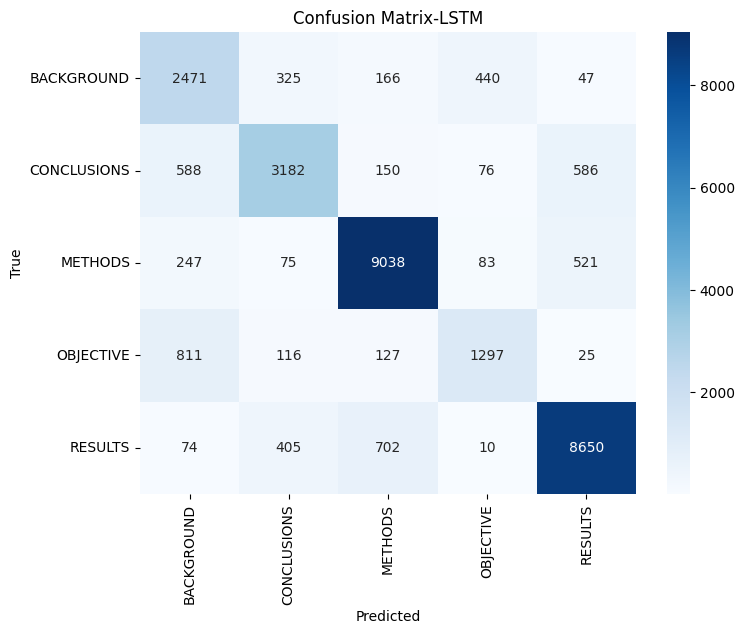

In [37]:
#visualize the Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt="d", xticklabels = label_encoder.classes_,
            yticklabels = label_encoder.classes_, cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix-LSTM")
plt.show()

In [38]:
## Class wise accuracy
class_accuracy = cm.diagonal()/cm.sum(axis=1)
for label, acc in zip(label_encoder.classes_, class_accuracy):
    print(f"{label}: {acc:3f}")

BACKGROUND: 0.716440
CONCLUSIONS: 0.694457
METHODS: 0.907065
OBJECTIVE: 0.545875
RESULTS: 0.878976


In [39]:
# Overall Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(val_true_classes, val_pred_classes)
print("Accuracy:", accuracy)

Accuracy: 0.8155037733350986


In [40]:
## Research-Level Evalauation 
from sklearn.metrics import f1_score

macro_f1 = f1_score(val_true_classes, val_pred_classes, average="macro")
weighted_f1 = f1_score(val_true_classes, val_pred_classes, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

Macro F1: 0.7524250878759402
Weighted F1: 0.815004137704415
